In [1]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_mfcc(df, segmented_dir, all_categories, n_mfcc=13, hop_length=512):
    segmented_dir = Path(segmented_dir)
    mfcc_list = []
    labels = []
    
    for index, f in tqdm(df.iterrows()):
        for file in segmented_dir.glob(f'{Path(f.fname).stem}_*.wav'):
            y, sr = librosa.load(file, sr=None)
            n_fft = min(2048, len(y))
            mfcc = librosa.feature.mfcc(y=y, 
                                        sr=sr, 
                                        n_mfcc=n_mfcc, 
                                        n_fft=n_fft, 
                                        hop_length=hop_length)
            mfcc_list.append(mfcc)
            labels.append(f.label)
        
    X = np.array(mfcc_list)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    label_encoder.fit(all_categories)
    y = label_encoder.transform(labels)

    return X, y

Load train/test DataFrame

In [3]:
train_csv_path = 'kaggle_meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

In [4]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [5]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('kaggle_data', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

Import data for model

In [6]:
X, y = create_mfcc(train_df, 'kaggle_segmented', musical_instruments)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

1847it [00:41, 44.51it/s]


Plot MFCC

In [7]:
def plot_mfcc(X, i=0, save_path=None):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

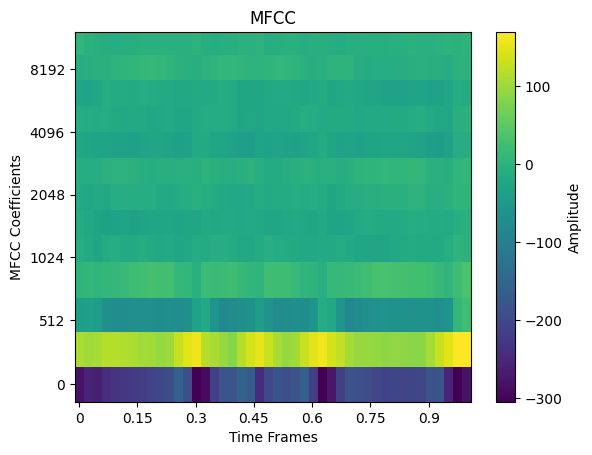

In [8]:
plot_mfcc(X, 0, 'kaggle_mfcc.png')

CNN model

In [9]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping], 
    class_weight=class_weights_dict
)

with open("kaggle_cnn_mfcc_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

Epoch 1/100
149/151 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2490 - loss: 2.3861
Epoch 1: val_accuracy improved from -inf to 0.61897, saving model to kaggle_cnn_mfcc.weights.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2507 - loss: 2.3794 - val_accuracy: 0.6190 - val_loss: 1.3012
Epoch 2/100
148/151 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4976 - loss: 1.5586
Epoch 2: val_accuracy improved from 0.61897 to 0.66805, saving model to kaggle_cnn_mfcc.weights.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4979 - loss: 1.5566 - val_accuracy: 0.6681 - val_loss: 0.9588
Epoch 3/100
147/151 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5568 - loss: 1.3027
Epoch 3: val_accuracy improved from 0.66805 to 0.69052, saving model to kaggle_cnn_mfcc.weights.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5571 - loss: 1.3019 - val_accuracy: 0.6905 - val_loss: 0.9065
Epoch 4/100
147/151 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6203 - loss: 1.0265
Epoc

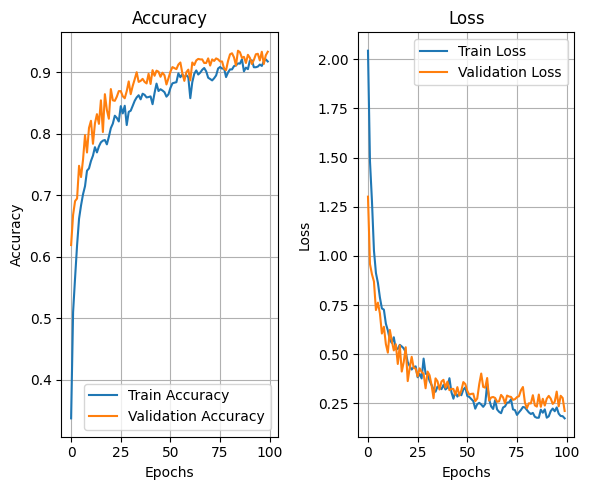

In [11]:
with open('kaggle_cnn_mfcc_history.pkl', 'rb') as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('kaggle_cnn_mfcc_training_curves.png')
plt.show()

Evaluate CNN

In [12]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = [musical_instruments[i] for i in y_pred]
y_test_labels = [musical_instruments[i] for i in y_test]

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'kaggle_cnn_mfcc_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .91

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Accuracy: 0.9081225033288948

Classification Report:
                   precision    recall  f1-score   support

 Acoustic_guitar       0.98      0.93      0.95        98
       Bass_drum       0.82      0.93      0.88        15
           Cello       0.83      0.90      0.86        21
        Clarinet       0.69      0.84      0.76        37
         Cowbell       0.74      0.98      0.84        63
     Double_bass       0.93      0.96      0.94        91
  Electric_piano       0.95      0.88      0.91       322
           Flute       0.93      0.92      0.92       167
    Glockenspiel       0.91      0.92      0.92       151
       Harmonica       0.96      0.93      0.95        28
          Hi-hat       0.83      0.85      0.84        71
            Oboe       0.99      0.80      0.88        95
       Saxophone       0.88      0.94      0.91        16
      Tambourine       0.88      0.91      0.89        23
         Trumpet       0.83      0.

Save CNN

In [13]:
# cnn.save('cnn_mfcc_model.h5')